In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('GEOS566 HW1.csv')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
daily=df.groupby('D')[['Dec','e2']].first()
daily=daily.interpolate().ffill().bfill()

df['Dec']=df['D'].map(daily['Dec'])
df['e2']=df['D'].map(daily['e2'])

In [4]:
#Fix units! Need radians for python trigonometric functions
df['Lat']=np.radians(df['Lat'])
df['Dec']=np.radians(df['Dec'])
df['H']=df['H']/100 #convert hours to 0-24 scale

#print(df)

In [5]:
#Defining constants

w=np.radians(15) # pi/12 rad per hour or 15 degrees per hour (angular velocity of Earth)
I0=1380 #W/m^2 (solar constant)

#Calculating cos(z)

df['cosz']=np.sin(df['Lat'])*np.sin(df['Dec']) + np.cos(df['Lat'])*np.cos(df['Dec'])*np.cos(w*(df['H']-12))


In [6]:
#potential solar radiation

df['I']=I0*df['cosz']/df['e2']

df.loc[df['I']<0,'I']=0

In [7]:
#Incorporating impact of cloud cover, inferring proportion of cloud cover as a function of range in daily temperature (assuming a flat spot, no impact of slope and aspect).

daily=df.groupby('D').agg({'Tmin':'min', 'Tmax':'max'})

daily['delT']=(daily['Tmax']-daily['Tmin'])

df['delT']=df['D'].map(daily['delT'])


df['Cf']=(1-np.exp(-0.01*df['delT']**2.4))

df['Icc']=df['I']*0.7*df['Cf']

print(df.columns)


Index(['D', 'H', 'Tsnow', 'Tmin', 'Tmax', 'Lat', 'Dec', 'e2', 'cosz', 'I',
       'delT', 'Cf', 'Icc'],
      dtype='object')


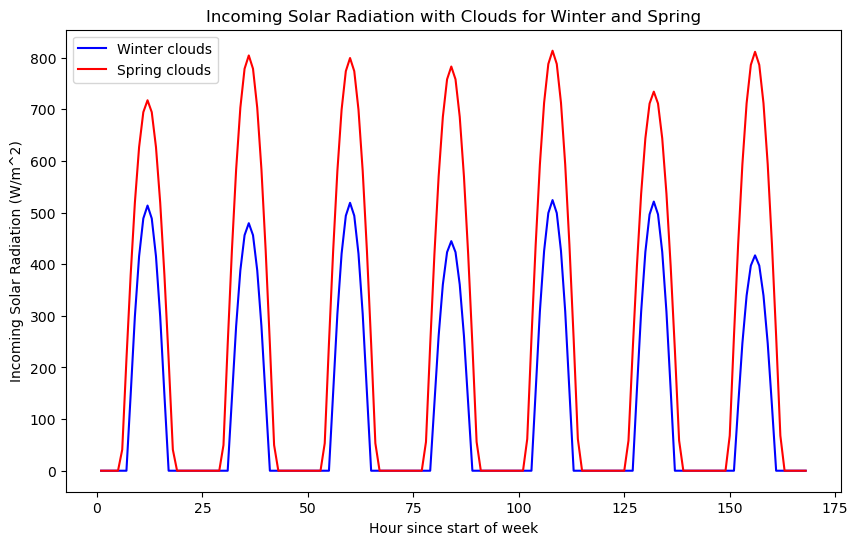

In [8]:
fig, ax = plt.subplots(figsize=(10,6))

winter=df[(df['D']>=15) & (df['D']<=21)].copy()
spring=df[(df['D']>=91) & (df['D']<=97)].copy()
winter['t']=24*(winter['D']-15)+winter['H']
spring['t']=24*(spring['D']-91)+spring['H']
ax.plot(winter['t'], winter['Icc'], label='Winter clouds', color='blue')
#ax.plot(winter['t'], winter['I'], label='Winter no clouds', color='cyan')
ax.plot(spring['t'], spring['Icc'], label='Spring clouds', color='red')
#ax.plot(spring['t'], spring['I'], label='Spring no clouds', color='orange')
ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Incoming Solar Radiation (W/m^2)')
ax.set_title('Incoming Solar Radiation with Clouds for Winter and Spring')
ax.legend()
plt.show()

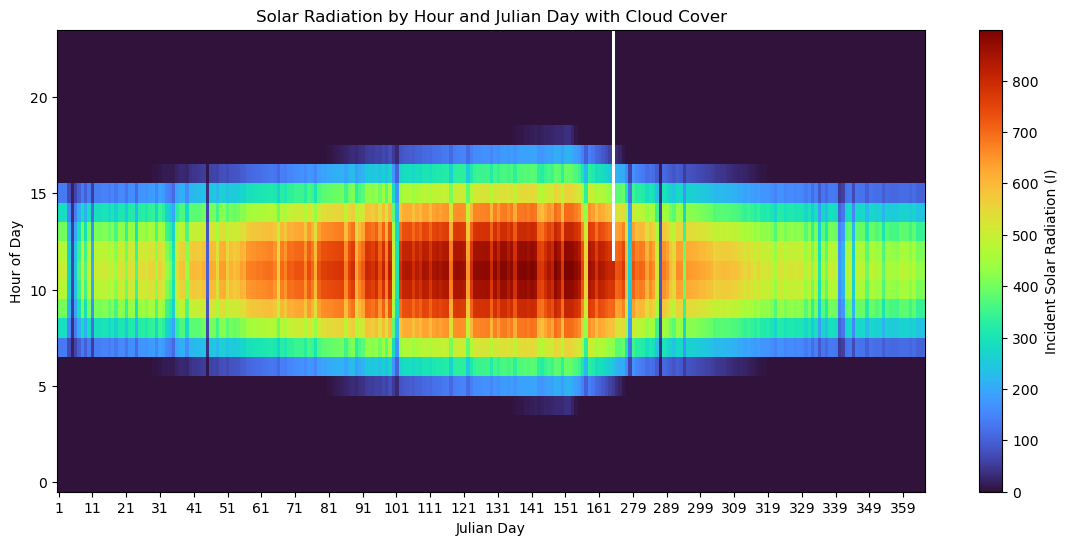

In [9]:
heatmap_data = df.pivot_table(index='H', columns='D', values='Icc')

plt.figure(figsize=(14,6))
# Plot the heatmap
plt.imshow(heatmap_data, aspect='auto', origin='lower', cmap='turbo')
plt.colorbar(label='Incident Solar Radiation (I)')  # color scale

plt.xlabel('Julian Day')
plt.ylabel('Hour of Day')
plt.title('Solar Radiation by Hour and Julian Day with Cloud Cover')

# Optional: make x-axis ticks less crowded
plt.xticks(ticks=np.arange(0, len(heatmap_data.columns), 10), 
           labels=heatmap_data.columns[::10])

plt.show()


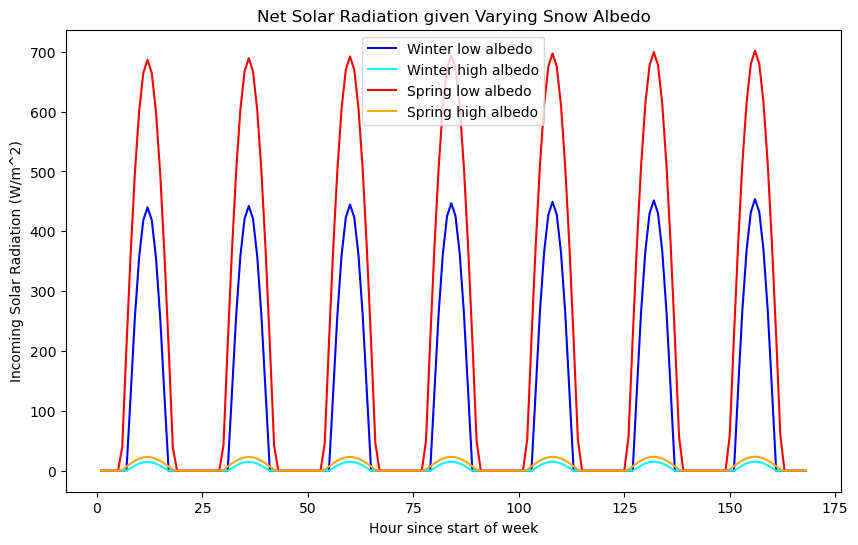

In [21]:
#Now dealing with albedo to get net direct solar radiation (ignoring cloud cover and assuming a flat spot with no slope)

df['I_low_albedo']=(1-0.4)*df['I']
df['I_high_albedo']=(1-0.98)*df['I']

fig, ax = plt.subplots(figsize=(10,6))

winter=df[(df['D']>=15) & (df['D']<=21)].copy()
spring=df[(df['D']>=91) & (df['D']<=97)].copy()
winter['t']=24*(winter['D']-15)+winter['H']
spring['t']=24*(spring['D']-91)+spring['H']
ax.plot(winter['t'], winter['I_low_albedo'], label='Winter low albedo', color='blue')
ax.plot(winter['t'], winter['I_high_albedo'], label='Winter high albedo', color='cyan')
ax.plot(spring['t'], spring['I_low_albedo'], label='Spring low albedo', color='red')
ax.plot(spring['t'], spring['I_high_albedo'], label='Spring high albedo', color='orange')
ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Incoming Solar Radiation (W/m^2)')
ax.set_title('Net Solar Radiation given Varying Snow Albedo')
ax.legend()
plt.show()

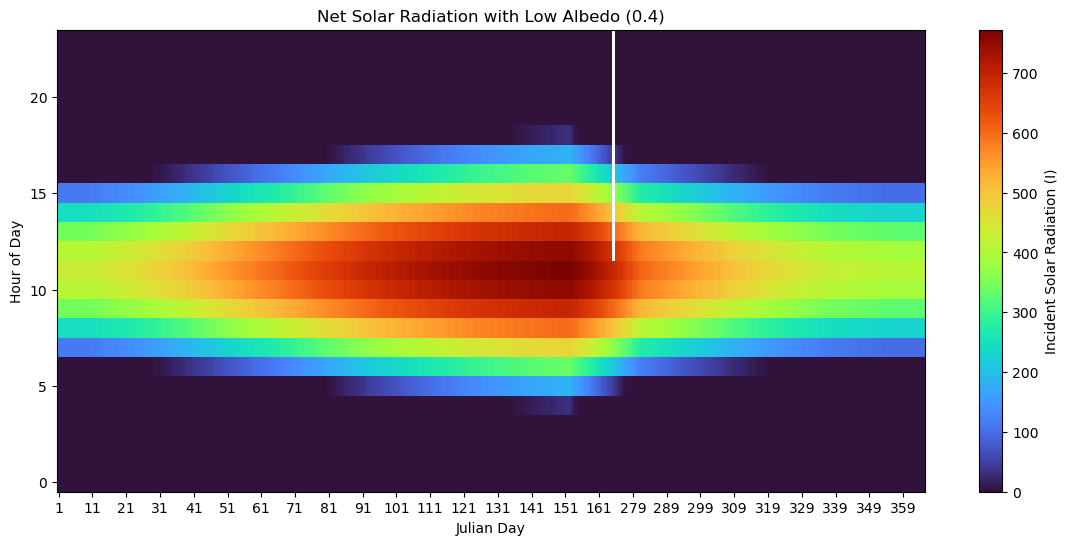

In [11]:
heatmap_data = df.pivot_table(index='H', columns='D', values='I_low_albedo')

plt.figure(figsize=(14,6))
# Plot the heatmap
plt.imshow(heatmap_data, aspect='auto', origin='lower', cmap='turbo')
plt.colorbar(label='Incident Solar Radiation (I)')  # color scale

plt.xlabel('Julian Day')
plt.ylabel('Hour of Day')
plt.title('Net Solar Radiation with Low Albedo (0.4)')

# Optional: make x-axis ticks less crowded
plt.xticks(ticks=np.arange(0, len(heatmap_data.columns), 10), 
           labels=heatmap_data.columns[::10])

plt.show()

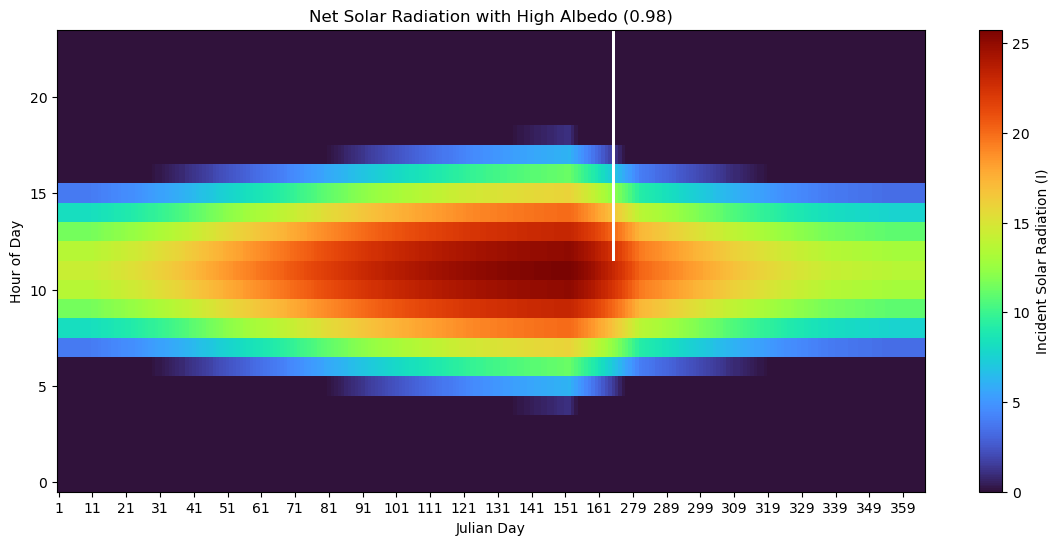

In [22]:
heatmap_data = df.pivot_table(index='H', columns='D', values='I_high_albedo')

plt.figure(figsize=(14,6))
# Plot the heatmap
plt.imshow(heatmap_data, aspect='auto', origin='lower', cmap='turbo')
plt.colorbar(label='Incident Solar Radiation (I)')  # color scale

plt.xlabel('Julian Day')
plt.ylabel('Hour of Day')
plt.title('Net Solar Radiation with High Albedo (0.98)')

# Optional: make x-axis ticks less crowded
plt.xticks(ticks=np.arange(0, len(heatmap_data.columns), 10), 
           labels=heatmap_data.columns[::10])

plt.show()

In [13]:
#Longwave Radiation INPUT into the snowpack assuming clear skies and emissivity of 0.98

sigma=5.67e-8 #W/m^2/K^4 (Stefan-Boltzmann constant)

df['Tav']=(df['Tmax']+df['Tmin'])/2
df['L_in']=0.98*sigma*(df['Tav']+273.15)**4

print(df.columns)

Index(['D', 'H', 'Tsnow', 'Tmin', 'Tmax', 'Lat', 'Dec', 'e2', 'cosz', 'I',
       'delT', 'Cf', 'Icc', 'I_low_albedo', 'I_high_albedo', 'Tav', 'L_in'],
      dtype='object')


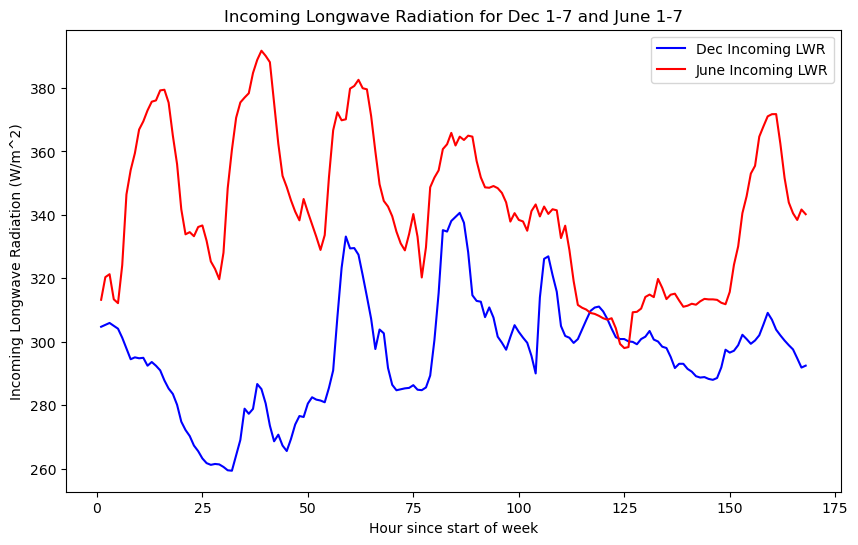

In [14]:
#Plotting incoming Longwave Radiation for Dec 1-7 and June 1-7

fig, ax = plt.subplots(figsize=(10,6))

dec=df[(df['D']>=335) & (df['D']<=341)].copy()
june=df[(df['D']>=152) & (df['D']<=158)].copy()
dec['t']=24*(dec['D']-335)+dec['H']
june['t']=24*(june['D']-152)+june['H']
ax.plot(dec['t'], dec['L_in'], label='Dec Incoming LWR', color='blue')
ax.plot(june['t'], june['L_in'], label='June Incoming LWR', color='red')
ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Incoming Longwave Radiation (W/m^2)')
ax.set_title('Incoming Longwave Radiation for Dec 1-7 and June 1-7')
ax.legend()
plt.show()

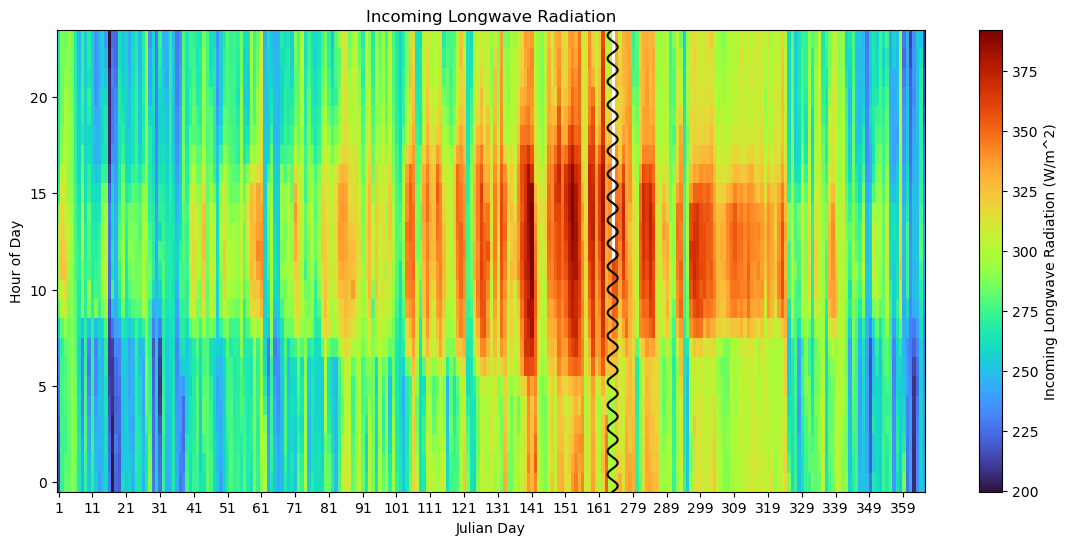

In [15]:
heatmap_data = df.pivot_table(index='H', columns='D', values='L_in')

plt.figure(figsize=(14,6))
# Plot the heatmap
plt.imshow(heatmap_data, aspect='auto', origin='lower', cmap='turbo')
plt.colorbar(label='Incoming Longwave Radiation (W/m^2)')  # color scale

plt.xlabel('Julian Day')
plt.ylabel('Hour of Day')
plt.title('Incoming Longwave Radiation')

# Optional: make x-axis ticks less crowded
plt.xticks(ticks=np.arange(0, len(heatmap_data.columns), 10), 
           labels=heatmap_data.columns[::10])

#Now I'm using ChatGPT to help me put a squiggly line on for the data gap I only just noticed!!!
#  your vertical break location
x0 = 164  

# get current y-limits so squiggle spans the plot
ymin, ymax = plt.ylim()

# create vertical range
y = np.linspace(ymin, ymax, 500)

# create small horizontal wiggle
amplitude = 1.5   # controls width of squiggle
frequency = 20    # controls number of wiggles

x = x0 + amplitude * np.sin(frequency * (y - ymin) / (ymax - ymin) * 2*np.pi)

plt.plot(x, y, c='k')

plt.show()

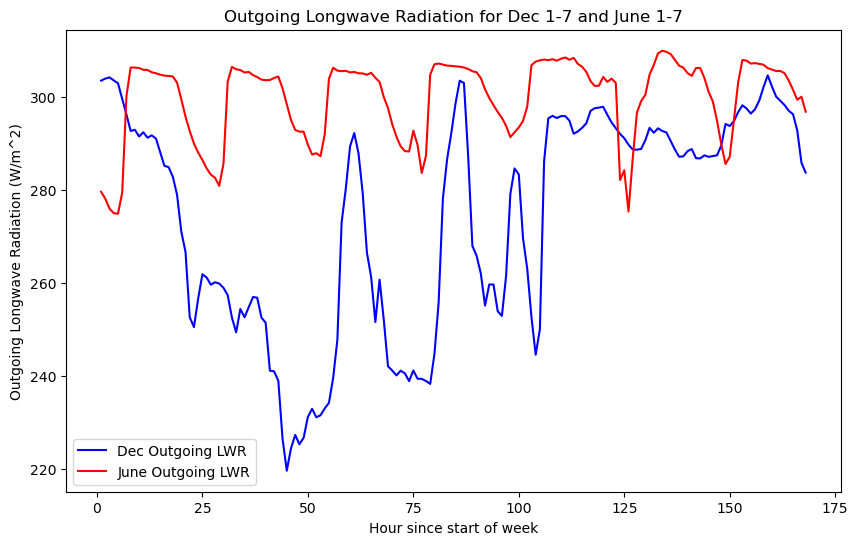

In [16]:
#Now determing longwave radiation emitted by the snowpack, assuming an emissivity of 0.98

df['L_out']=0.98*sigma*(df['Tsnow']+273.15)**4

#Plotting incoming Longwave Radiation for Dec 1-7 and June 1-7

fig, ax = plt.subplots(figsize=(10,6))

dec=df[(df['D']>=335) & (df['D']<=341)].copy()
june=df[(df['D']>=152) & (df['D']<=158)].copy()
dec['t']=24*(dec['D']-335)+dec['H']
june['t']=24*(june['D']-152)+june['H']
ax.plot(dec['t'], dec['L_out'], label='Dec Outgoing LWR', color='blue')
ax.plot(june['t'], june['L_out'], label='June Outgoing LWR', color='red')
ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Outgoing Longwave Radiation (W/m^2)')
ax.set_title('Outgoing Longwave Radiation for Dec 1-7 and June 1-7')
ax.legend()
plt.show()

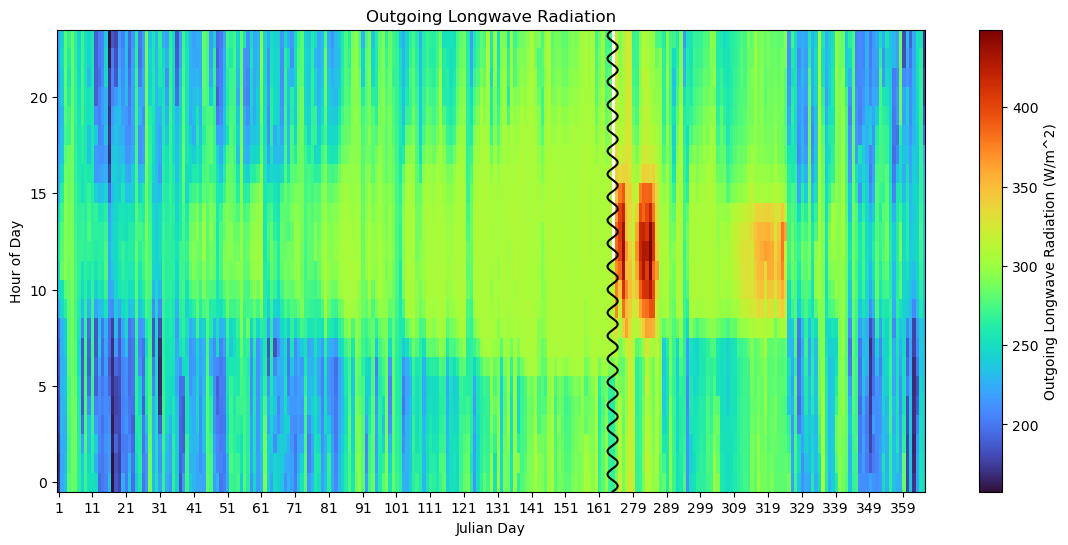

In [17]:
heatmap_data = df.pivot_table(index='H', columns='D', values='L_out')

plt.figure(figsize=(14,6))
# Plot the heatmap
plt.imshow(heatmap_data, aspect='auto', origin='lower', cmap='turbo')
plt.colorbar(label='Outgoing Longwave Radiation (W/m^2)')  # color scale

plt.xlabel('Julian Day')
plt.ylabel('Hour of Day')
plt.title('Outgoing Longwave Radiation')

# Optional: make x-axis ticks less crowded
plt.xticks(ticks=np.arange(0, len(heatmap_data.columns), 10), 
           labels=heatmap_data.columns[::10])
#Now I'm using ChatGPT to help me put a squiggly line on for the data gap I only just noticed!!!
#  your vertical break location
x0 = 164  

# get current y-limits so squiggle spans the plot
ymin, ymax = plt.ylim()

# create vertical range
y = np.linspace(ymin, ymax, 500)

# create small horizontal wiggle
amplitude = 1.5   # controls width of squiggle
frequency = 20    # controls number of wiggles

x = x0 + amplitude * np.sin(frequency * (y - ymin) / (ymax - ymin) * 2*np.pi)

plt.plot(x, y, c='k')

plt.show()

In [18]:
df['L_net']=df['L_in']-df['L_out']
df['S_net']=df['I_high_albedo']
df['R_net']=df['S_net']+df['L_net']

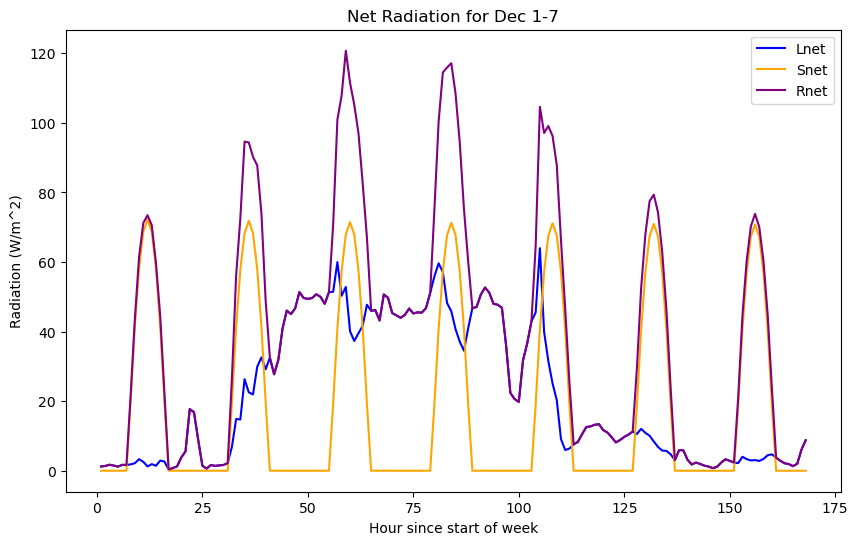

In [19]:
#Plotting net LW, net SW, and net radiation for Dec 1-7

fig, ax = plt.subplots(figsize=(10,6))

dec=df[(df['D']>=335) & (df['D']<=341)].copy()
june=df[(df['D']>=152) & (df['D']<=158)].copy()
dec['t']=24*(dec['D']-335)+dec['H']
june['t']=24*(june['D']-152)+june['H']
ax.plot(dec['t'], dec['L_net'], label='Lnet', color='blue')
ax.plot(dec['t'], dec['S_net'], label='Snet', color='orange')
ax.plot(dec['t'], dec['R_net'], label='Rnet', color='purple')

ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Radiation (W/m^2)')
ax.set_title('Net Radiation for Dec 1-7')
ax.legend()
plt.show()

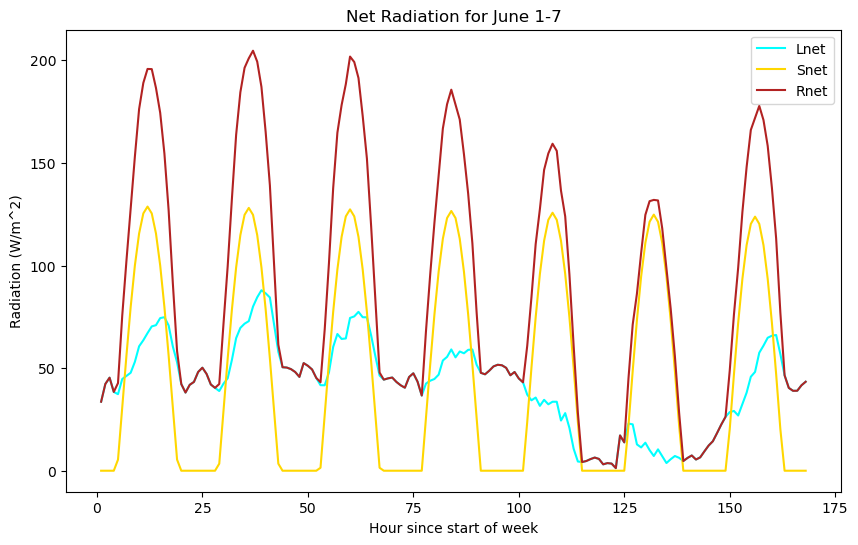

In [20]:
#Plotting net LW, net SW, and net radiation for June 1-7

fig, ax = plt.subplots(figsize=(10,6))

dec=df[(df['D']>=335) & (df['D']<=341)].copy()
june=df[(df['D']>=152) & (df['D']<=158)].copy()
dec['t']=24*(dec['D']-335)+dec['H']
june['t']=24*(june['D']-152)+june['H']
ax.plot(june['t'], june['L_net'], label='Lnet', color='cyan')
ax.plot(june['t'], june['S_net'], label='Snet', color='gold')
ax.plot(june['t'], june['R_net'], label='Rnet', color='firebrick')
ax.set_xlabel('Hour since start of week')
ax.set_ylabel('Radiation (W/m^2)')
ax.set_title('Net Radiation for June 1-7')
ax.legend()
plt.show()



In [23]:
df['Lncc']=(df['L_in']*(1+0.2*df['Cf']))-df['L_out']
df['Sncc_lowa']=(1-0.5)*df['Icc']
df['Sncc_higha']=(1-0.98)*df['Icc']
df['Rncc_lowa']=df['Lncc']+df['Sncc_lowa']
df['Rncc_higha']=df['Lncc']+df['Sncc_higha']

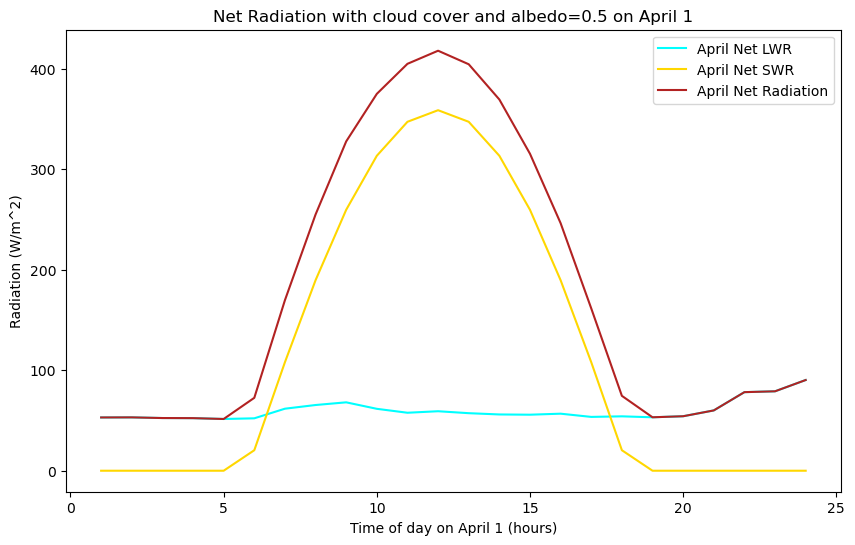

In [24]:
#Plotting net LW, net SW, and net radiation for June 1-7

fig, ax = plt.subplots(figsize=(10,6))

april=df[(df['D']==91)].copy()
ax.plot(april['H'], april['Lncc'], label='April Net LWR', color='cyan')
ax.plot(april['H'], april['Sncc_lowa'], label='April Net SWR', color='gold')
ax.plot(april['H'], april['Rncc_lowa'], label='April Net Radiation', color='firebrick')
ax.set_xlabel('Time of day on April 1 (hours)')
ax.set_ylabel('Radiation (W/m^2)')
ax.set_title('Net Radiation with cloud cover and albedo=0.5 on April 1')
ax.legend()
plt.show()

In [25]:
df['R_net_lowa']=df['L_net']+df['I_low_albedo']
df['R_net_higha']=df['L_net']+df['I_high_albedo']

print(df.columns)

Index(['D', 'H', 'Tsnow', 'Tmin', 'Tmax', 'Lat', 'Dec', 'e2', 'cosz', 'I',
       'delT', 'Cf', 'Icc', 'I_low_albedo', 'I_high_albedo', 'Tav', 'L_in',
       'L_out', 'L_net', 'S_net', 'R_net', 'Lncc', 'Sncc_lowa', 'Sncc_higha',
       'Rncc_lowa', 'Rncc_higha', 'R_net_lowa', 'R_net_higha'],
      dtype='object')


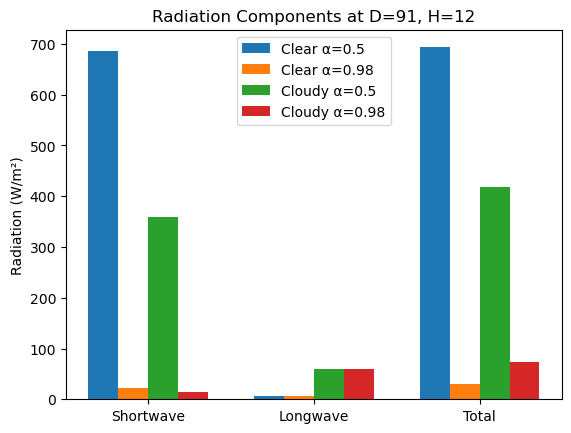

In [26]:
subset=df[(df['D']==91)&(df['H']==12)]

clear_lowa  = [subset['I_low_albedo'].values[0],
               subset['L_net'].values[0],
               subset['R_net_lowa'].values[0]]

clear_higha = [subset['I_high_albedo'].values[0],
               subset['L_net'].values[0],
               subset['R_net_higha'].values[0]]

cloudy_lowa = [subset['Sncc_lowa'].values[0],
               subset['Lncc'].values[0],
               subset['Rncc_lowa'].values[0]]

cloudy_higha = [subset['Sncc_higha'].values[0],
                subset['Lncc'].values[0],
                subset['Rncc_higha'].values[0]]

labels = ['Shortwave', 'Longwave', 'Total']
x = np.arange(len(labels))  # 0,1,2
width = 0.18

fig, ax = plt.subplots()

ax.bar(x - 1.5*width, clear_lowa,  width, label='Clear α=0.5')
ax.bar(x - 0.5*width, clear_higha, width, label='Clear α=0.98')
ax.bar(x + 0.5*width, cloudy_lowa, width, label='Cloudy α=0.5')
ax.bar(x + 1.5*width, cloudy_higha,width, label='Cloudy α=0.98')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Radiation (W/m²)')
ax.set_title('Radiation Components at D=91, H=12')
ax.legend()

plt.show()


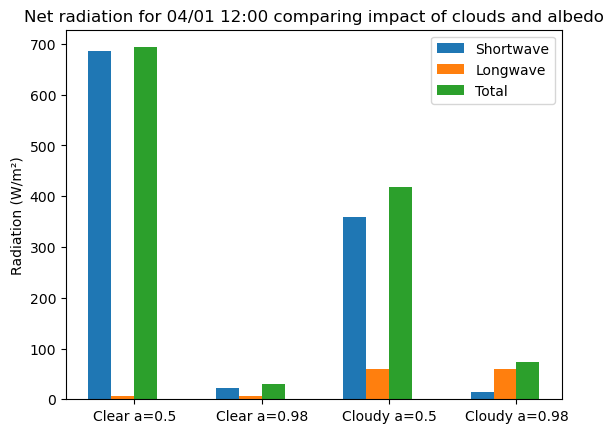

         L_net       Lncc
4379  6.656654  59.196835


In [28]:
subset=df[(df['D']==91)&(df['H']==12)]

sw_sub=[subset['I_low_albedo'].values[0], subset['I_high_albedo'].values[0], subset['Sncc_lowa'].values[0], subset['Sncc_higha'].values[0]]
lw_sub=[subset['L_net'].values[0], subset['L_net'].values[0], subset['Lncc'].values[0], subset['Lncc'].values[0]]
r_sub=[subset['R_net_lowa'].values[0], subset['R_net_higha'].values[0], subset['Rncc_lowa'].values[0], subset['Rncc_higha'].values[0]]

labels = ['Clear a=0.5', 'Clear a=0.98', 'Cloudy a=0.5', 'Cloudy a=0.98']
x = np.arange(len(labels)) 
width = 0.18

fig, ax = plt.subplots()

ax.bar(x - 1.5*width, sw_sub,  width, label='Shortwave')
ax.bar(x - 0.5*width, lw_sub, width, label='Longwave')
ax.bar(x + 0.5*width, r_sub, width, label='Total')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Radiation (W/m²)')
ax.set_title('Net radiation for 04/01 12:00 comparing impact of clouds and albedo')
ax.legend()

plt.show()

print(subset[['L_net','Lncc']])
